Cell 1: Database Setup & Data Extraction

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

# 1. Connect to PostgreSQL
DB_USER = "postgres"
DB_PASS = "admin123"  # Replace if your PostgreSQL password differs
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "ecommerce_db"

engine = create_engine(
    f"postgresql+psycopg://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# 2. Extract RFM Segments using the SQL logic
rfm_query = """
WITH cleaned_transactions AS (
    SELECT 
        customer_id,
        invoice_no,
        invoice_date,
        (quantity * unit_price) AS line_total
    FROM raw_transactions
    WHERE customer_id IS NOT NULL 
      AND quantity > 0
      AND unit_price > 0
),
reference_date AS (
    SELECT MAX(invoice_date)::DATE + INTERVAL '1 day' AS snapshot_date
    FROM cleaned_transactions
),
rfm_metrics AS (
    SELECT 
        t.customer_id,
        (r.snapshot_date::DATE - MAX(t.invoice_date)::DATE) AS recency_days,
        COUNT(DISTINCT t.invoice_no) AS frequency_orders,
        ROUND(SUM(t.line_total)::NUMERIC, 2) AS monetary_value
    FROM cleaned_transactions t
    CROSS JOIN reference_date r
    GROUP BY t.customer_id, r.snapshot_date
),
rfm_scores AS (
    SELECT 
        customer_id,
        recency_days,
        frequency_orders,
        monetary_value,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency_orders ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary_value ASC) AS m_score
    FROM rfm_metrics
),
rfm_composite AS (
    SELECT 
        customer_id,
        recency_days,
        frequency_orders,
        monetary_value,
        r_score,
        f_score,
        m_score,
        (r_score::TEXT || f_score::TEXT || m_score::TEXT) AS rfm_cell
    FROM rfm_scores
)
SELECT 
    customer_id,
    recency_days,
    frequency_orders,
    monetary_value,
    r_score,
    f_score,
    m_score,
    rfm_cell,
    CASE 
        WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
        WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal Customers'
        WHEN r_score >= 4 AND f_score <= 2 THEN 'Recent New Customers'
        WHEN r_score >= 3 AND f_score <= 2 THEN 'Promising'
        WHEN r_score = 3 AND f_score = 3 THEN 'Need Attention'
        WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk'
        WHEN r_score <= 2 AND f_score <= 2 THEN 'Hibernating / Lost'
        ELSE 'Potential Loyalist'
    END AS customer_segment
FROM rfm_composite;
"""

df_rfm = pd.read_sql(rfm_query, con=engine)
print(f"Successfully loaded {len(df_rfm):,} customer profiles.")
df_rfm.head()

Successfully loaded 18,000 customer profiles.


,customer_id,recency_days,frequency_orders,monetary_value,r_score,f_score,m_score,rfm_cell,customer_segment
0,CUST_17288,660,16,1391.59,1,1,1,111,Hibernating / Lost
1,CUST_27296,647,20,1326.29,1,1,1,111,Hibernating / Lost
2,CUST_20867,645,18,853.69,1,1,1,111,Hibernating / Lost
3,CUST_22361,645,28,2058.22,1,3,3,133,At Risk
4,CUST_27574,644,28,2334.42,1,3,4,134,At Risk


Cell 2: Aggregate Executive Summary Table

In [2]:
# Compute business KPIs per customer segment
segment_summary = (
    df_rfm.groupby("customer_segment")
    .agg(
        customer_count=("customer_id", "count"),
        avg_recency=("recency_days", "mean"),
        avg_frequency=("frequency_orders", "mean"),
        avg_monetary=("monetary_value", "mean"),
        total_revenue=("monetary_value", "sum"),
    )
    .reset_index()
)

# Calculate percentages for portfolio reporting
total_rev = segment_summary["total_revenue"].sum()
total_cust = segment_summary["customer_count"].sum()

segment_summary["pct_customers"] = (
    segment_summary["customer_count"] / total_cust * 100
).round(1)
segment_summary["pct_revenue"] = (
    segment_summary["total_revenue"] / total_rev * 100
).round(1)

# Sort by revenue contribution
segment_summary = segment_summary.sort_values(
    by="total_revenue", ascending=False
)
segment_summary.round(2)

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
0,At Risk,4272,424.86,30.44,2328.37,9946795.86,23.7,26.6
3,Loyal Customers,4653,129.07,29.63,2106.53,9801674.76,25.8,26.2
1,Champions,1875,53.28,32.98,2884.87,5409135.76,10.4,14.4
2,Hibernating / Lost,2928,431.10,22.15,1690.26,4949072.18,16.3,13.2
5,Recent New Customers,2779,53.18,22.32,1726.63,4798295.22,15.4,12.8
4,Promising,1493,219.78,22.28,1700.72,2539171.24,8.3,6.8


Cell 3: Revenue & Customer Volume Distribution Chart

C:\Users\kmdsa\AppData\Local\Temp\ipykernel_12836\3837396393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\kmdsa\AppData\Local\Temp\ipykernel_12836\3837396393.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


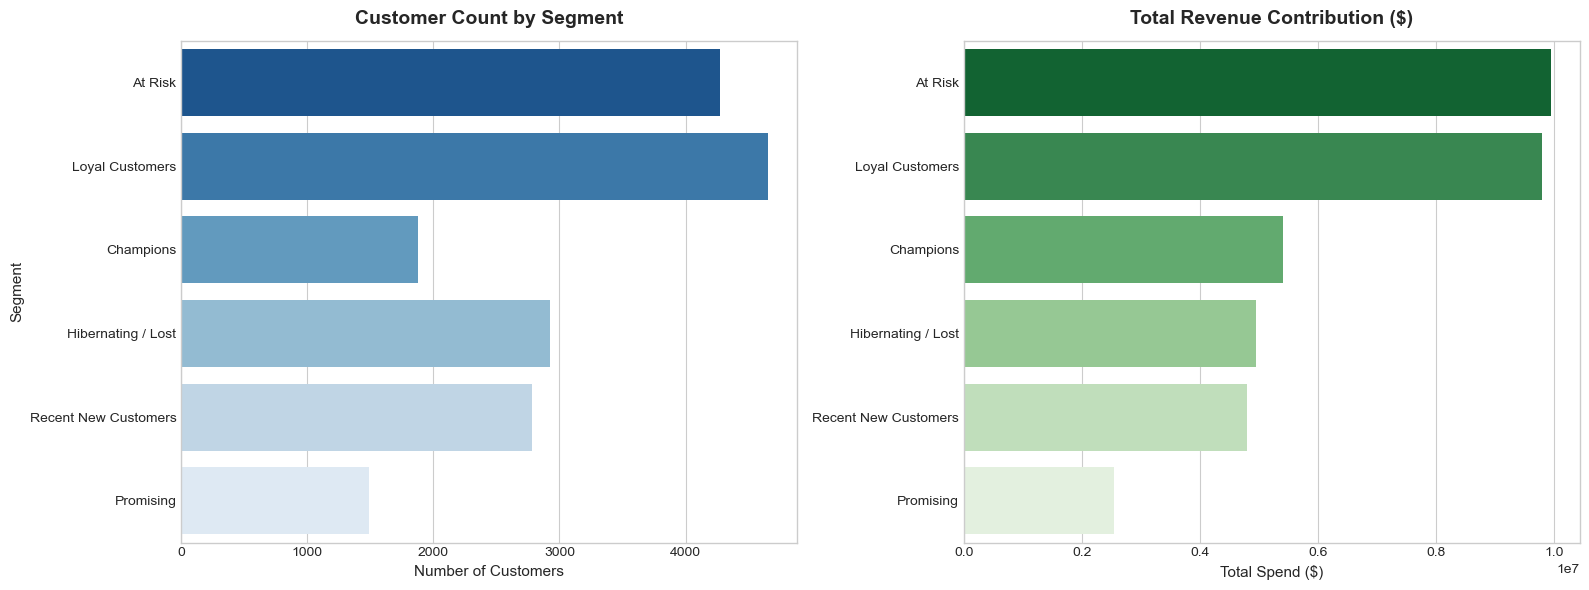

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Customer Count by Segment
sns.barplot(
    data=segment_summary,
    x="customer_count",
    y="customer_segment",
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title(
    "Customer Count by Segment", fontsize=14, fontweight="bold", pad=12
)
axes[0].set_xlabel("Number of Customers", fontsize=11)
axes[0].set_ylabel("Segment", fontsize=11)

# Plot 2: Total Revenue Contribution by Segment
sns.barplot(
    data=segment_summary,
    x="total_revenue",
    y="customer_segment",
    palette="Greens_r",
    ax=axes[1],
)
axes[1].set_title(
    "Total Revenue Contribution ($)", fontsize=14, fontweight="bold", pad=12
)
axes[1].set_xlabel("Total Spend ($)", fontsize=11)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../notebooks/rfm_segment_distribution.png", dpi=300)
plt.show()

Cell 4: Recency vs. Frequency vs. Monetary Scatter Plot

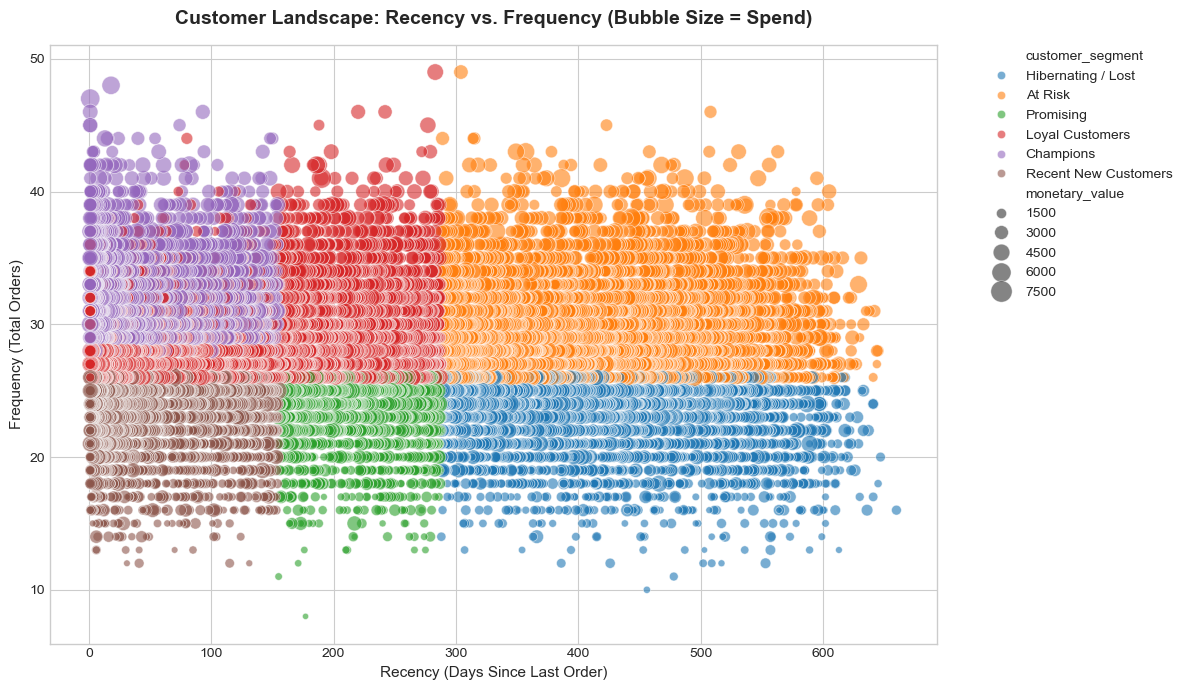

In [4]:
plt.figure(figsize=(12, 7))

# Scatter plot: Recency (X) vs Frequency (Y), bubble size = Monetary
sns.scatterplot(
    data=df_rfm,
    x="recency_days",
    y="frequency_orders",
    hue="customer_segment",
    size="monetary_value",
    sizes=(20, 250),
    alpha=0.6,
    palette="tab10",
)

plt.title(
    "Customer Landscape: Recency vs. Frequency (Bubble Size = Spend)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Recency (Days Since Last Order)", fontsize=11)
plt.ylabel("Frequency (Total Orders)", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)

plt.tight_layout()
plt.savefig("../notebooks/rfm_scatter_distribution.png", dpi=300)
plt.show()

Cohort Retention Analysis & Heatmap

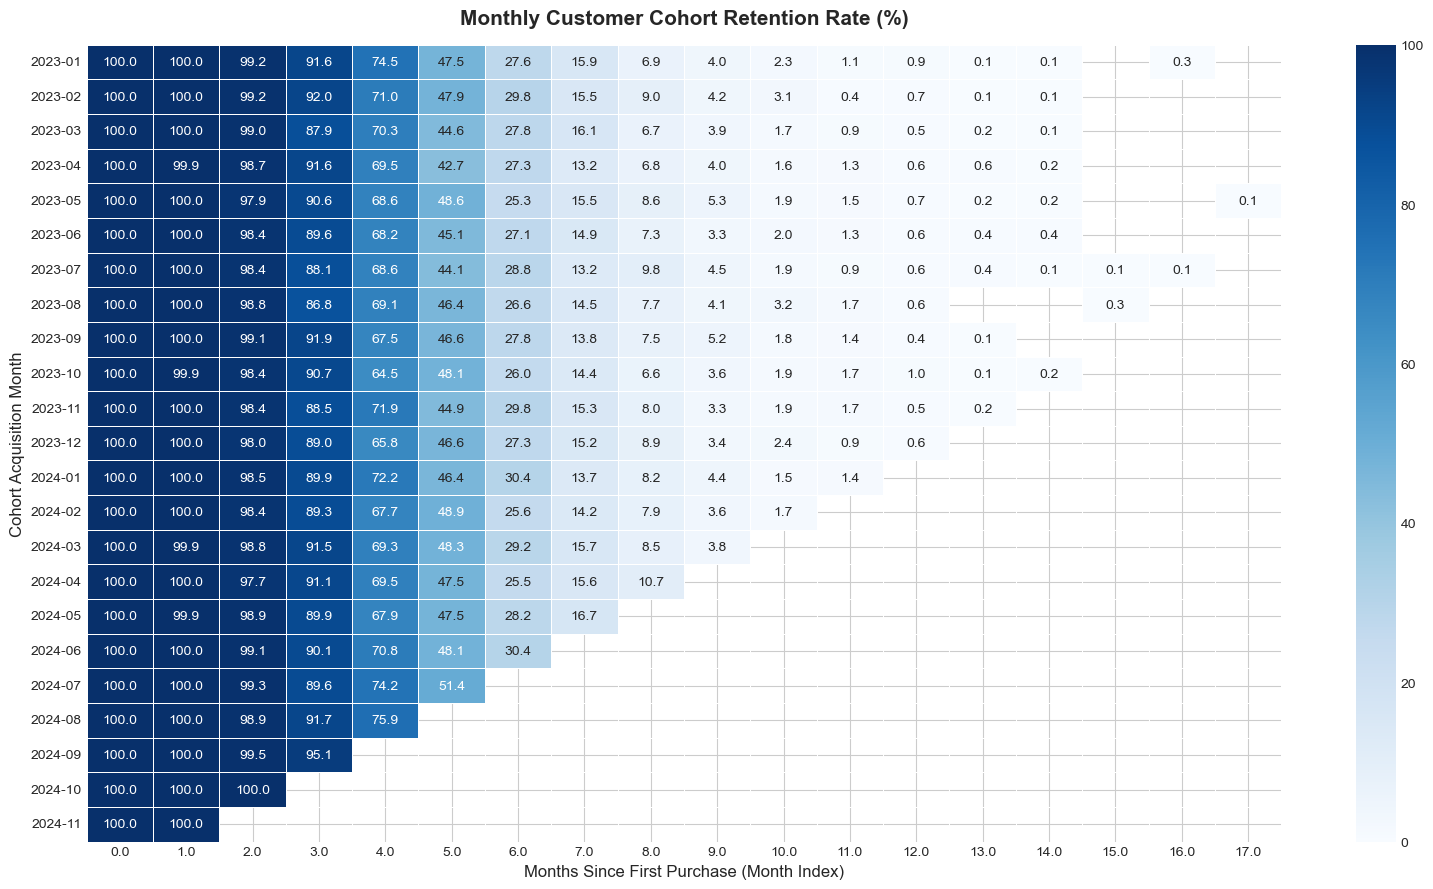

Cohort Retention Heatmap saved successfully as cohort_retention_heatmap.png!


In [5]:
# ==========================================
# Step 1: Cohort Retention Analysis & Heatmap
# ==========================================

cohort_sql = """
WITH customer_first_purchase AS (
    SELECT 
        customer_id,
        DATE_TRUNC('month', MIN(invoice_date))::DATE AS cohort_month
    FROM raw_transactions
    WHERE customer_id IS NOT NULL 
      AND quantity > 0
    GROUP BY customer_id
),
transaction_activity AS (
    SELECT DISTINCT
        customer_id,
        DATE_TRUNC('month', invoice_date)::DATE AS purchase_month
    FROM raw_transactions
    WHERE customer_id IS NOT NULL 
      AND quantity > 0
),
cohort_indexed AS (
    SELECT 
        c.cohort_month,
        t.purchase_month,
        (EXTRACT(YEAR FROM t.purchase_month) - EXTRACT(YEAR FROM c.cohort_month)) * 12 +
        (EXTRACT(MONTH FROM t.purchase_month) - EXTRACT(MONTH FROM c.cohort_month)) AS month_number,
        c.customer_id
    FROM customer_first_purchase c
    JOIN transaction_activity t 
      ON c.customer_id = t.customer_id
),
cohort_sizes AS (
    SELECT 
        cohort_month,
        COUNT(DISTINCT customer_id) AS cohort_size
    FROM customer_first_purchase
    GROUP BY cohort_month
),
cohort_retention AS (
    SELECT 
        ci.cohort_month,
        cs.cohort_size,
        ci.month_number,
        COUNT(DISTINCT ci.customer_id) AS retained_customers
    FROM cohort_indexed ci
    JOIN cohort_sizes cs 
      ON ci.cohort_month = cs.cohort_month
    GROUP BY ci.cohort_month, cs.cohort_size, ci.month_number
)
SELECT 
    cohort_month,
    cohort_size,
    month_number,
    retained_customers,
    ROUND((retained_customers::NUMERIC / cohort_size) * 100, 1) AS retention_rate_pct
FROM cohort_retention
ORDER BY cohort_month, month_number;
"""

# 1. Execute query and pull from PostgreSQL
df_cohort = pd.read_sql(cohort_sql, con=engine)

# 2. Format cohort date and pivot into a matrix
df_cohort['cohort_label'] = pd.to_datetime(df_cohort['cohort_month']).dt.strftime('%Y-%m')
retention_matrix = df_cohort.pivot(
    index='cohort_label', 
    columns='month_number', 
    values='retention_rate_pct'
)

# 3. Render heatmap visualization
plt.figure(figsize=(16, 9))
sns.heatmap(
    retention_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="Blues", 
    vmin=0, 
    vmax=100, 
    linewidths=0.5
)
plt.title("Monthly Customer Cohort Retention Rate (%)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Months Since First Purchase (Month Index)", fontsize=12)
plt.ylabel("Cohort Acquisition Month", fontsize=12)
plt.tight_layout()

# 4. Save clean 300 DPI asset for your README and portfolio
plt.savefig("../notebooks/cohort_retention_heatmap.png", dpi=300)
plt.show()

print("Cohort Retention Heatmap saved successfully as cohort_retention_heatmap.png!")

Purchase Velocity Analysis

Calculated purchase velocity for 18,000 repeat customers.


C:\Users\kmdsa\AppData\Local\Temp\ipykernel_12836\2098861209.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


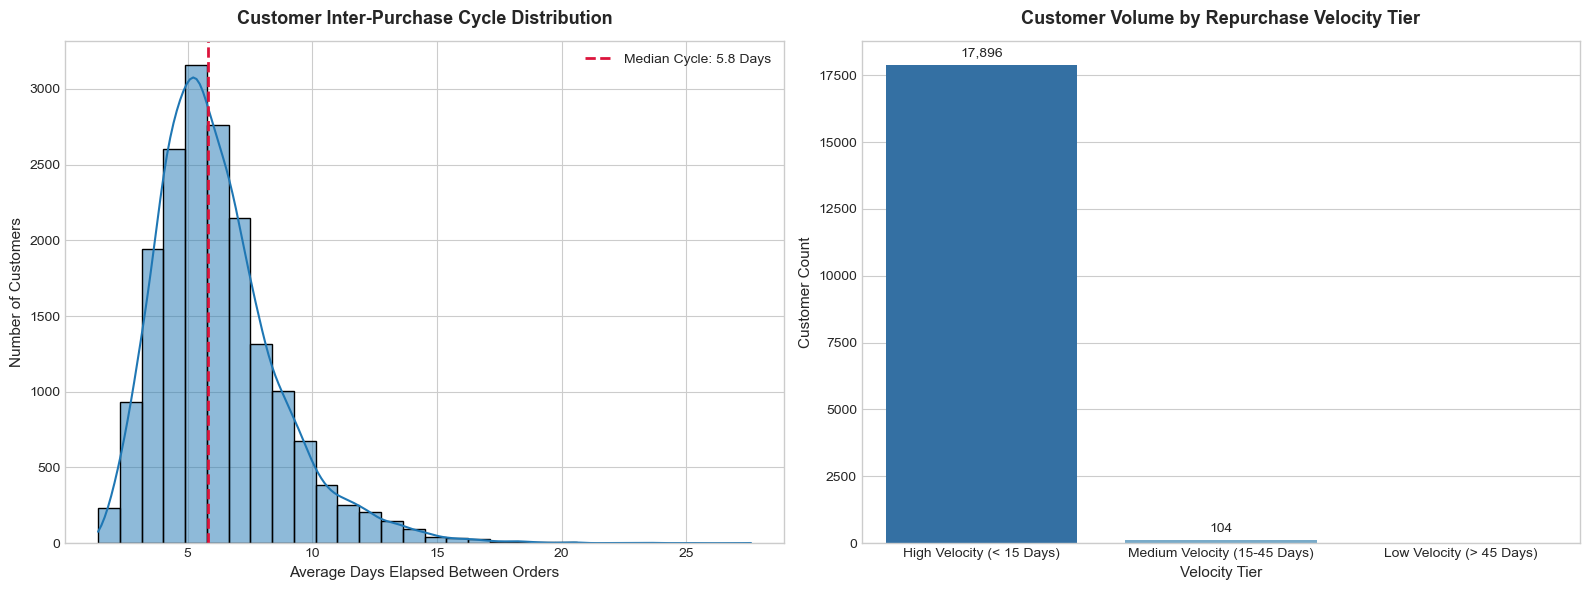

Purchase Velocity asset saved successfully as purchase_velocity_distribution.png!


In [6]:
# ==========================================
# Step 2: Purchase Velocity Analysis
# ==========================================

velocity_sql = """
WITH distinct_orders AS (
    SELECT DISTINCT
        customer_id,
        invoice_no,
        invoice_date::DATE AS order_date
    FROM raw_transactions
    WHERE customer_id IS NOT NULL 
      AND quantity > 0
),
order_lags AS (
    -- Use LAG() window function to capture the customer's prior order date
    SELECT 
        customer_id,
        invoice_no,
        order_date,
        LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) AS prev_order_date
    FROM distinct_orders
),
inter_purchase_intervals AS (
    -- Compute the elapsed days between sequential orders
    SELECT 
        customer_id,
        invoice_no,
        order_date,
        prev_order_date,
        (order_date - prev_order_date) AS days_between_orders
    FROM order_lags
    WHERE prev_order_date IS NOT NULL
)
SELECT 
    customer_id,
    COUNT(*) AS total_repeat_orders,
    ROUND(AVG(days_between_orders), 1) AS avg_cycle_days,
    MIN(days_between_orders) AS min_cycle_days,
    MAX(days_between_orders) AS max_cycle_days,
    CASE 
        WHEN AVG(days_between_orders) <= 15 THEN 'High Velocity (< 15 Days)'
        WHEN AVG(days_between_orders) <= 45 THEN 'Medium Velocity (15-45 Days)'
        ELSE 'Low Velocity (> 45 Days)'
    END AS velocity_tier
FROM inter_purchase_intervals
GROUP BY customer_id
ORDER BY total_repeat_orders DESC, avg_cycle_days ASC;
"""

# 1. Execute query and pull from PostgreSQL
df_velocity = pd.read_sql(velocity_sql, con=engine)
print(f"Calculated purchase velocity for {len(df_velocity):,} repeat customers.")

# 2. Build executive velocity summary table
velocity_summary = (
    df_velocity.groupby("velocity_tier")
    .agg(
        customer_count=("customer_id", "count"),
        avg_repeat_orders=("total_repeat_orders", "mean"),
        avg_cycle_days=("avg_cycle_days", "mean"),
    )
    .reset_index()
)

tier_order = [
    "High Velocity (< 15 Days)",
    "Medium Velocity (15-45 Days)",
    "Low Velocity (> 45 Days)",
]
velocity_summary["velocity_tier"] = pd.Categorical(
    velocity_summary["velocity_tier"], categories=tier_order, ordered=True
)
velocity_summary = velocity_summary.sort_values("velocity_tier").reset_index(
    drop=True
)
velocity_summary["pct_customers"] = (
    velocity_summary["customer_count"]
    / velocity_summary["customer_count"].sum()
    * 100
).round(1)

# 3. Create two-panel velocity visual asset
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Distribution of inter-purchase cycle days
sns.histplot(
    data=df_velocity,
    x="avg_cycle_days",
    kde=True,
    bins=30,
    color="#1f77b4",
    ax=axes[0],
)
axes[0].axvline(
    df_velocity["avg_cycle_days"].median(),
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Median Cycle: {df_velocity['avg_cycle_days'].median():.1f} Days",
)
axes[0].set_title(
    "Customer Inter-Purchase Cycle Distribution",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
axes[0].set_xlabel("Average Days Elapsed Between Orders", fontsize=11)
axes[0].set_ylabel("Number of Customers", fontsize=11)
axes[0].legend()

# Right Plot: Volume breakdown by velocity tier
sns.barplot(
    data=velocity_summary,
    x="velocity_tier",
    y="customer_count",
    palette="Blues_r",
    ax=axes[1],
)
axes[1].set_title(
    "Customer Volume by Repurchase Velocity Tier",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Velocity Tier", fontsize=11)
axes[1].set_ylabel("Customer Count", fontsize=11)

# Add exact value annotations on the bars
for bar in axes[1].patches:
    val = bar.get_height()
    axes[1].annotate(
        f"{int(val):,}",
        (bar.get_x() + bar.get_width() / 2.0, val),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.tight_layout()

# 4. Save clean visual asset for your portfolio
plt.savefig("../notebooks/purchase_velocity_distribution.png", dpi=300)
plt.show()

print(
    "Purchase Velocity asset saved successfully as purchase_velocity_distribution.png!"
)

High-Value Churn Risk Engine: Combining RFM with Velocity

EXECUTIVE CHURN INTERVENTION SUMMARY
VIP Customers Monitored: 6,528
VIP Customers Currently Overdue: 5,815
Total Historical Spend at Immediate Risk: $13,558,047.24


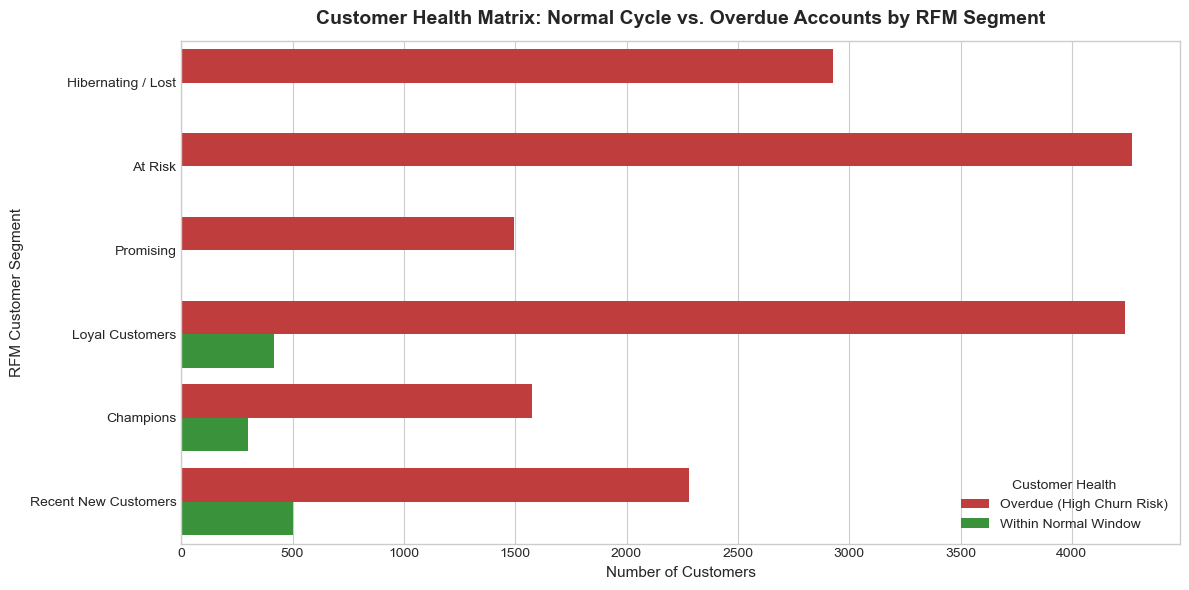

In [7]:
# ==========================================================
# High-Value Churn Risk Engine: Combining RFM with Velocity
# ==========================================================

# 1. Join customer RFM classifications with their historical velocity intervals
df_risk = pd.merge(df_rfm, df_velocity, on="customer_id", how="inner")

# 2. Flag overdue status: has customer recency exceeded 1.5x their historical inter-purchase average?
df_risk['churn_status'] = np.where(
    df_risk['recency_days'] > (df_risk['avg_cycle_days'] * 1.5),
    'Overdue (High Churn Risk)',
    'Within Normal Window'
)

# 3. Filter for revenue-critical accounts (Champions & Loyal Customers)
vip_risk = df_risk[
    (df_risk['customer_segment'].isin(['Champions', 'Loyal Customers'])) & 
    (df_risk['churn_status'] == 'Overdue (High Churn Risk)')
]

total_vip_revenue_at_risk = vip_risk['monetary_value'].sum()

print("=" * 60)
print("EXECUTIVE CHURN INTERVENTION SUMMARY")
print("=" * 60)
print(f"VIP Customers Monitored: {len(df_risk[df_risk['customer_segment'].isin(['Champions', 'Loyal Customers'])]):,}")
print(f"VIP Customers Currently Overdue: {len(vip_risk):,}")
print(f"Total Historical Spend at Immediate Risk: ${total_vip_revenue_at_risk:,.2f}")
print("=" * 60)

# 4. Generate the Executive Intervention Visual
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_risk,
    y="customer_segment",
    hue="churn_status",
    palette={"Within Normal Window": "#2ca02c", "Overdue (High Churn Risk)": "#d62728"}
)
plt.title("Customer Health Matrix: Normal Cycle vs. Overdue Accounts by RFM Segment", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Number of Customers", fontsize=11)
plt.ylabel("RFM Customer Segment", fontsize=11)
plt.legend(title="Customer Health", loc="lower right")
plt.tight_layout()

# Save final visual asset
plt.savefig("../notebooks/rfm_velocity_retention_risk.png", dpi=300)
plt.show()